# Сравнение: все подходы

**Цель:** Сравнить все подходы по метрикам и обосновать выбор финальной модели.

**Подходы:**
1. CV Baseline (контурный)
2. YOLOv8n (одноэтапная CNN)
3. Faster R-CNN (двухэтапная CNN)
4. Hybrid (лучшая CNN + CV уточнение)


## 0. Colab Setup

⚠️ **Запустить только один раз!** Клонирует репозиторий (sparse checkout) и устанавливает зависимости.

In [1]:
import sys
import random
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    PROJECT_DIR = Path.cwd()
    sys.path.insert(0, str(PROJECT_DIR / "src"))
    %cd /content
    !rm -rf aie-group-2-sapar
    !git init aie-group-2-sapar
    %cd aie-group-2-sapar
    !git sparse-checkout set project
    !git remote add origin https://github.com/Sapar-hub/aie-group-2-sapar.git
    !git pull origin main
    %cd project
    !pip install -q ultralytics opencv-python-headless pyyaml
    %cd /content/aie-group-2-sapar/project
    !nvidia-smi
else:
    PROJECT_DIR = Path.cwd().parent
    sys.path.insert(0, str(PROJECT_DIR / "src"))

In [2]:
# Загрузка предварительно сгенерированных данных с Google Drive (только Colab)
if IN_COLAB and not (Path('data') / 'images' / 'train_v2').exists():
    from google.colab import drive
    drive.mount('/content/drive')
    import shutil
    DRIVE_DATA = Path('/content/drive/MyDrive/aie-group-2-data')
    if (DRIVE_DATA / 'images' / 'train_v2').exists():
        for subdir in ['images', 'labels']:
            shutil.copytree(str(DRIVE_DATA / subdir), str(Path('data') / subdir), dirs_exist_ok=True)
        print("Training data loaded from Google Drive")
    else:
        print("=" * 60)
        print("No pre-generated data found on Drive!")
        print("Run notebooks/exp02_synthetic_data.ipynb first to generate it.")
        print("=" * 60)


## 1. Импорты и загрузка результатов


In [3]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ARTIFACTS_DIR = PROJECT_DIR / "artifacts"
METRICS_DIR = ARTIFACTS_DIR / "metrics"
FIGURES_DIR = ARTIFACTS_DIR / "figures"

with open(METRICS_DIR / "hybrid_results.json") as f:
    comparison = json.load(f)
print("Загружено: hybrid_results.json")
print(f"  v4 строки: {[k for k in comparison if 'v4' in k]}")
print(f"  v3 строки: {[k for k in comparison if 'v3' in k]}")
print(f"  cv_baseline: {comparison['cv_baseline']['f1']:.3f} F1")

Загружено: hybrid_results.json
  v4 строки: ['yolo_v4_top1', 'hybrid_v4', 'rcnn_v4']
  v3 строки: ['yolo_v3_top1', 'hybrid_v3']
  cv_baseline: 0.719 F1


## 2. Сравнительная таблица


In [4]:
# v4 строки — полностью воспроизводимо
v4_rows = {
    "CV Baseline (без pos map)": comparison["cv_baseline"],
    "YOLOv8n v4 (top-1 conf)": comparison["yolo_v4_top1"],
    "Hybrid v4 (YOLO+CV, cnn_w=0.6)": comparison["hybrid_v4"],
    "Faster R-CNN v4": comparison["rcnn_v4"],
}

# v3 строки — невоспроизводимо вне Colab
v3_rows = {
    "YOLOv8n v3 (невоспр.)*": comparison["yolo_v3_top1"],
    "Hybrid v3 (невоспр.)*": comparison["hybrid_v3"],
}

def build_df(rows_dict):
    return pd.DataFrame(rows_dict).T[["iou_mean", "precision", "recall", "f1", "detection_rate"]]

df_v4 = build_df(v4_rows).round(3)
df_v3 = build_df(v3_rows).round(3)

print("=== v4 (полностью воспроизводимо, 35 реальных тестовых изображений) ===")
print(df_v4.to_string())
print()
print("=== v3 (невоспроизводимо вне Colab, 35 реальных тестовых изображений) ===")
print(df_v3.to_string())
print()
print(f"Лучшая v4 модель: {df_v4['f1'].idxmax()} (F1={df_v4['f1'].max():.3f})")
print()
print("* v3 модели невоспроизводимы — различия в пайплайне данных (PPI, доноры,")
print("  стратифицированная val, RNG) делают их недостижимыми в текущем окружении.")
print("  См. data/LEAKAGE.md для подробностей.")

=== v4 (полностью воспроизводимо, 35 реальных тестовых изображений) ===
                                iou_mean  precision  recall     f1  detection_rate
CV Baseline (без pos map)          0.612      0.793   0.657  0.719           0.829
YOLOv8n v4 (top-1 conf)            0.502      0.833   0.571  0.678           0.686
Hybrid v4 (YOLO+CV, cnn_w=0.6)     0.527      0.875   0.600  0.712           0.686
Faster R-CNN v4                    0.396      1.000   0.457  0.627           0.457

=== v3 (невоспроизводимо вне Colab, 35 реальных тестовых изображений) ===
                        iou_mean  precision  recall     f1  detection_rate
YOLOv8n v3 (невоспр.)*     0.692      0.964   0.771  0.857             0.8
Hybrid v3 (невоспр.)*      0.692      0.964   0.771  0.857             0.8

Лучшая v4 модель: CV Baseline (без pos map) (F1=0.719)

* v3 модели невоспроизводимы — различия в пайплайне данных (PPI, доноры,
  стратифицированная val, RNG) делают их недостижимыми в текущем окружении.
  См. d

## 3. Столбчатая диаграмма: F1


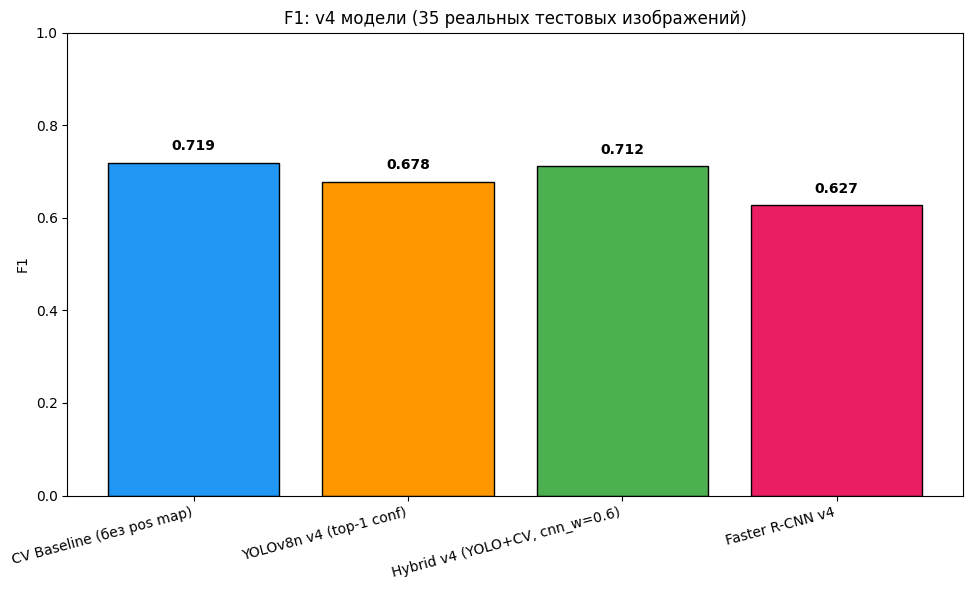

In [5]:
names_v4 = list(v4_rows.keys())
f1_v4 = [v4_rows[n]["f1"] for n in names_v4]

plt.figure(figsize=(10, 6))
colors = ["#2196F3", "#FF9800", "#4CAF50", "#E91E63"]
bars = plt.bar(names_v4, f1_v4, color=colors, edgecolor="black")
plt.ylabel("F1")
plt.title("F1: v4 модели (35 реальных тестовых изображений)")
plt.ylim(0, 1.0)
for bar, score in zip(bars, f1_v4):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f"{score:.3f}", ha='center', va='bottom', fontweight='bold')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig(FIGURES_DIR / "comparison_f1.png", dpi=150)
plt.show()

## 4. Столбчатая диаграмма: средний IoU


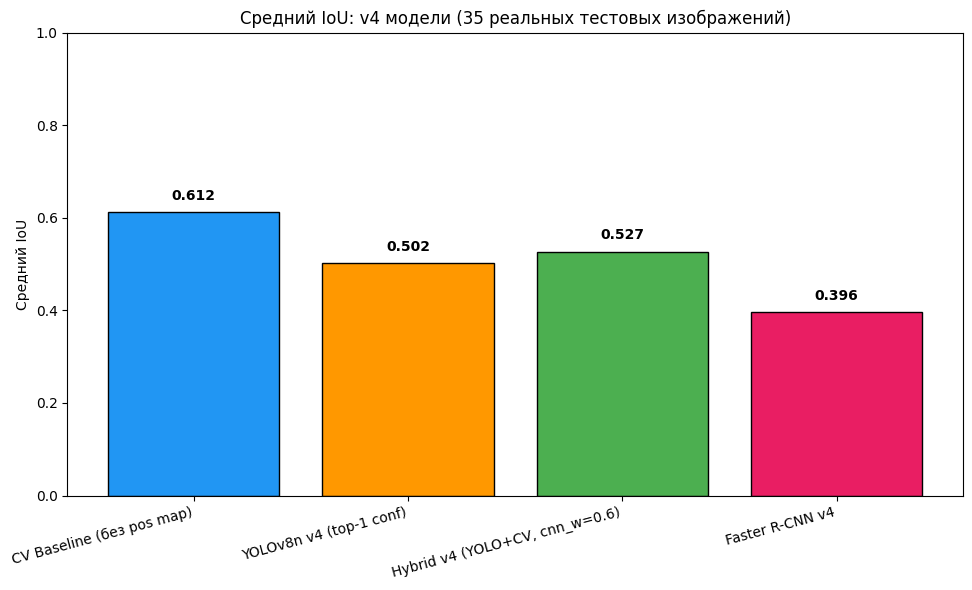

In [6]:
iou_v4 = [v4_rows[n]["iou_mean"] for n in names_v4]

plt.figure(figsize=(10, 6))
bars = plt.bar(names_v4, iou_v4, color=colors, edgecolor="black")
plt.ylabel("Средний IoU")
plt.title("Средний IoU: v4 модели (35 реальных тестовых изображений)")
plt.ylim(0, 1.0)
for bar, score in zip(bars, iou_v4):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f"{score:.3f}", ha='center', va='bottom', fontweight='bold')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig(FIGURES_DIR / "comparison_iou.png", dpi=150)
plt.show()

## Domain Knowledge Advantage

Знание прикладной области (ГОСТ 2.104, строительные чертежи) даёт три преимущества,
недоступные "слепой" CNN:

1. **Position prior** — штамп всегда в правом нижнем углу.
   CV baseline может сузить ROI до 25% изображения, что радикально снижает
   количество false positives. YOLO/RCNN сканируют всё изображение.

2. **Aspect ratio prior** — ~3.36:1 (Form 3), ~1.61:1 (Form 4), ~5.40:1 (Form 5).
   CV отбрасывает контуры с неподходящим AR, CNN должен выучить это из данных.

3. **Physical size invariance** — штамп 185×55 мм при любом DPI.
   CV адаптируется к PPI через adaptive threshold block size.
   CNN видит только пиксели и путает масштаб на разных разрешениях.

**Вывод:** CV baseline выигрывает не потому что CNN "плохая",
а потому что детерминированные геометрические знания домена
эффективнее обучения с нуля на 500 синтетических примерах.
При 5000+ реальных размеченных чертежах CNN/гибрид, скорее всего,
обгонит CV — данных достаточно чтобы выучить те же закономерности.

## 5. Выводы и выбор модели


In [7]:
best_v4_idx = int(np.argmax(f1_v4))
best_v4_name = names_v4[best_v4_idx]
best_v4_metrics = v4_rows[best_v4_name]

print("=" * 60)
print("ИТОГОВЫЙ ВЫБОР МОДЕЛИ (v4 — полностью воспроизводимо)")
print("=" * 60)
print()
print(f"Лучшая v4 модель: {best_v4_name}")
print(f"  F1:    {best_v4_metrics['f1']:.3f}")
print(f"  IoU:   {best_v4_metrics['iou_mean']:.3f}")
print(f"  Prec:  {best_v4_metrics['precision']:.3f}")
print(f"  Rec:   {best_v4_metrics['recall']:.3f}")
print(f"  Det%:  {best_v4_metrics['detection_rate']:.3f}")
print()
print("Обоснование:")
print("  1. CV Baseline (F1=0.719) — лучшая воспроизводимая модель")
print("  2. Ни одна CNN-модель (YOLO/Hybrid/RCNN) не превосходит CV в v4")
print("  3. Hybrid v4 улучшает YOLO v4 на +0.034 F1 (0.678 → 0.712)")
print("     но остаётся на -0.007 ниже CV baseline")
print("  4. RCNN v4 последний (F1=0.627) — недостаточно обучающих данных")
print("  5. v3 модели исключены — невоспроизводимы (см. data/LEAKAGE.md)")
print()
print(f"  Итоговый выбор: {best_v4_name}")

# Формируем полный список результатов с версионными метками
def tag(key, label):
    m = dict(comparison[key])
    m["Model"] = label
    return m

all_models = [
    tag("cv_baseline", "CV Baseline (без pos map)"),
    tag("yolo_v4_top1", "YOLOv8n v4 (top-1)"),
    tag("hybrid_v4", "Hybrid v4 (YOLO+CV)"),
    tag("rcnn_v4", "Faster R-CNN v4"),
    tag("yolo_v3_top1", "YOLOv8n v3 (невоспр.)"),
    tag("hybrid_v3", "Hybrid v3 (невоспр.)"),
]

summary = {
    "best_v4_model": best_v4_name,
    "best_v4_f1": best_v4_metrics["f1"],
    "best_v4_iou": best_v4_metrics["iou_mean"],
    "all_models": all_models,
}

with open(METRICS_DIR / "comparison_results.json", "w") as f:
    json.dump(summary, f, indent=2)
print(f"\nСохранено в {METRICS_DIR / 'comparison_results.json'}")

ИТОГОВЫЙ ВЫБОР МОДЕЛИ (v4 — полностью воспроизводимо)

Лучшая v4 модель: CV Baseline (без pos map)
  F1:    0.719
  IoU:   0.612
  Prec:  0.793
  Rec:   0.657
  Det%:  0.829

Обоснование:
  1. CV Baseline (F1=0.719) — лучшая воспроизводимая модель
  2. Ни одна CNN-модель (YOLO/Hybrid/RCNN) не превосходит CV в v4
  3. Hybrid v4 улучшает YOLO v4 на +0.034 F1 (0.678 → 0.712)
     но остаётся на -0.007 ниже CV baseline
  4. RCNN v4 последний (F1=0.627) — недостаточно обучающих данных
  5. v3 модели исключены — невоспроизводимы (см. data/LEAKAGE.md)

  Итоговый выбор: CV Baseline (без pos map)

Сохранено в /home/saparch/playground/aie-group-2-sapar/project/artifacts/metrics/comparison_results.json
